<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQhd1XNuDQpQDaKAsWg7XIjvb5CHoBbOiMlBw&s" width = "800" height = "300">


# 🚗 Parking Occupancy Node Project Report

## ✍️ **Authors:**
- ✨ **Mostafa Moazenkakhki** → **ID: 11033591**
- ✨ **Mohammad Tabatabaei** → **ID: 10967133**





## 📖 Project Overview

This project focuses on developing a parking occupancy node using the **ESP32 microcontroller** integrated with an **HC-SR04 ultrasonic distance sensor**. The node is emulated using the **Wokwi platform**, designed to detect and communicate the occupancy status of a parking spot to a central ESP32 sink node using the **ESP-NOW protocol**. Additionally, the node utilizes a **Deep Sleep mode** with a defined duty-cycle to enhance energy efficiency.

---

## 📑 Table of Contents

- [🔍 Overview of the Project](#-overview-of-the-project)

- [1️⃣ Part 1 - Parking Occupancy Node Specification](#1️⃣-part-1---parking-occupancy-node-specification)

- [2️⃣ Part 2 - Energy Consumption Estimation](#2️⃣-part-2---energy-consumption-estimation)
  - [Estimate the Average Power Consumption](#estimate-the-average-power-consumption)
  - [Estimate the Energy Consumption of One Transmission Cycle](#estimate-the-energy-consumption-of-one-transmission-cycle)

- [3️⃣ Part 3 - Improvements Aiming to Reduce Energy Consumption](#3️⃣-part-3---improvements-aiming-to-reduce-energy-consumption)

- [4️⃣ Part 4 - System Lifetime & Sink Optimization](#4️⃣-part-4---system-lifetime--sink-optimization)
  - [Find the Lifetime of the System](#find-the-lifetime-of-the-system)
  - [Find the Optimal Position of the Sink](#find-the-optimal-position-of-the-sink)
  - [Discuss the Trade-offs](#discuss-the-trade-offs)

---






## 🎯 Project Goal

Develop a simple parking occupancy node using an **ESP32 microcontroller** and the **HC-SR04 ultrasonic distance sensor** on the **Wokwi emulator**. The node will communicate the parking occupancy status to a central ESP32 sink node using the **ESP-NOW communication protocol** and utilize **Deep Sleep mode** with a defined duty-cycle for improved power efficiency.

---

## 📌 Parking Occupancy Node Specifications

### 🎯 Objective

The node aims to:

- 📏 Detect the occupancy of a parking spot by measuring distance using the **HC-SR04 ultrasonic sensor**.
- 📡 Communicate the occupancy status to a central **ESP32 sink node** via **ESP-NOW protocol**.

### 🛑 Occupancy Detection Logic

- The **HC-SR04 ultrasonic sensor** measures the distance between the sensor and a parked vehicle.
- **Occupancy Criterion:** A parking spot is considered occupied if the measured distance is **≤ 50 cm**.

### 🛠️ Hardware and Software Emulation

- **Emulator Platform:** Wokwi
- **Microcontroller:** ESP32
- **Sensor:** HC-SR04 Ultrasonic Distance Sensor
      
### 🔋 Power Management

- Implement **Deep Sleep mode** for energy efficiency.
- Configure a **Deep Sleep duty-cycle** (`X` seconds sleep interval, to be defined according to project requirements).

    #### 🕒 Duty Cycle Calculation
    For the duty cycle period, compute **X** as follows:
    
    Take the last two digits of the **team leader's person code**, perform **modulo 50**, and add **5**:
    
    ```markdown
    _Leader Person Code_ = 106929**AB**
    ```
    
    Thus, **X** is calculated as:
    
    ```markdown
    X = **AB** % 50 + **5**
    ```

    After calculation, we get X = 27 Seconds

# HC-SR04 Ultrasonic Sensor
<img src="https://www.rhydolabz.com/image/cache/catalog/36/SEN3692_3-1000x1000.webp" width="600" height="300">

The **HC-SR04** is a popular ultrasonic distance sensor used in various electronics and IoT projects. It uses sound waves to measure distances with high accuracy.

## Features:
- **Operating Voltage**: 5V DC
- **Measuring Range**: 2cm - 400cm
- **Accuracy**: ±3mm
- **Frequency**: 40kHz

## Working Principle:
1. The **Trigger Pin** sends a **10µs** HIGH pulse.
2. The sensor emits an ultrasonic sound wave.
3. The wave reflects off an object and returns to the **Echo Pin**.
4. The time taken for the wave to return is used to calculate the distance.

## Connection with Arduino:
| HC-SR04 Pin | Arduino Pin |
|-------------|------------|
| VCC         | 5V         |
| Trig        | Any Digital Pin |
| Echo        | Any Digital Pin |
| GND         | GND        |

## Formula for Distance Calculation:
$$
Distance(cm) = \frac{Pulse\ Duration(\mu s) \times 0.0343}{2}
$$



---
# 🚗 Part 1: Parking occupancy node Specification




#  Parking Spot Sensor and Communication Code

This code checks whether a parking spot is free or occupied using an ultrasonic sensor. The result is sent using ESP-NOW, and then the device enters deep sleep mode to conserve power.



## 📚 1. Libraries

```c
#include <WiFi.h>
#include <esp_now.h>
```

- **Explanation**:  
  - `WiFi.h` provides WiFi functions for the board.  
  - `esp_now.h` enables sending messages without a traditional WiFi network.



## 🎛️ 2. Pins and Global Variables


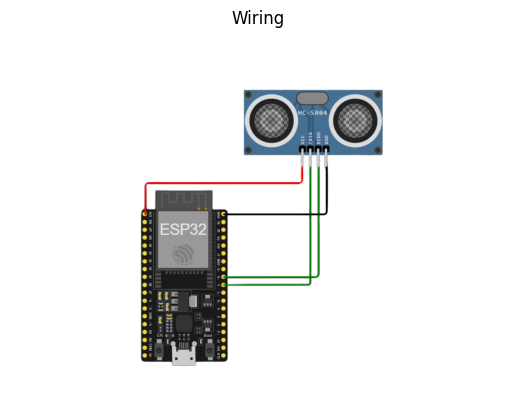

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/content/pic (2).png')

plt.imshow(img)
plt.axis('off')
plt.title("Wiring")
plt.show()


```c
// Pins for the ultrasonic sensor
const int TRIG = 5;
const int ECHO = 18;

// Sleep time in seconds
const int X = 27;

// Receiver's MAC Address for ESP-NOW
uint8_t broadcastAddress[] = {0x8C, 0xAA, 0xB5, 0x84, 0xFB, 0x90};

esp_now_peer_info_t peerInfo;
```

- **Explanation**:  
  - `TRIG` and `ECHO` connect to the ultrasonic sensor.  
  - `X` sets the sleep duration before waking up again.  
  - `broadcastAddress` holds the receiver's MAC address for sending data.



## 📏 3. Checking the Distance

```c
String check_distance() {
  Serial.println("Sensor Starts Measurement at " + String(millis()));

  // Trigger the sensor to send a pulse
  digitalWrite(TRIG, LOW);
  delayMicroseconds(2);
  digitalWrite(TRIG, HIGH);
  delayMicroseconds(10);
  digitalWrite(TRIG, LOW);

  // Read the time taken for the echo to return
  int duration = pulseIn(ECHO, HIGH);

  Serial.println("Sensor Ends Measurement at " + String(millis()));

  // Calculate the distance in centimeters
  int distance = duration / 58;
  String result;

  if (distance < 50) {
    result = "OCCUPIED";
  }
  else {
    result = "FREE";
  }
  return result;
}
```

- **Explanation**:  
  - The sensor sends a pulse and measures the time for the echo to return.  
  - The duration is converted into a distance (in cm).  
  - A distance less than 50 cm marks the spot as "OCCUPIED"; otherwise, it is "FREE."



## 📤 4. Send Callback

```c
void data_sent(const uint8_t * mac_addr, esp_now_send_status_t status) {
  Serial.print("Send status: ");
  Serial.println(status == ESP_NOW_SEND_SUCCESS ? "OK" : "Error");
}
```

- **Explanation**:  
  - This callback reports whether the message was sent successfully ("OK") or if an error occurred ("Error").



## 📥 5. Receive Callback

```c
void data_recv(const esp_now_recv_info_t* recv_info, const uint8_t* data, int len) {
  Serial.println("Received Successfully");

  // Create a string from the received data with null termination
  char received_string[len + 1];
  memcpy(received_string, data, len);
  received_string[len] = '\0';
  Serial.println("Received Message is " + String(received_string));
}
```

- **Explanation**:  
  - Triggered upon receiving a message, this callback converts the data into a string and prints it.



## 📶 6. WiFi Setup and Data Sending

```c
void wifi_setup(String result) {
  // Configure the receiver's address
  memcpy(peerInfo.peer_addr, broadcastAddress, 6);
  peerInfo.channel = 0;
  peerInfo.encrypt = false;

  // Set WiFi power and start WiFi
  WiFi.setTxPower(WIFI_POWER_2dBm);
  Serial.println("Wifi Start at " + String(millis()));

  // Set the device to station mode and initialize ESP-NOW
  WiFi.mode(WIFI_STA);
  delay(100);
  esp_now_init();
  esp_now_add_peer(&peerInfo);
  Serial.println("Start Sending at " + String(millis()));

  // Register the send and receive callback functions
  esp_now_register_send_cb(data_sent);
  esp_now_register_recv_cb(data_recv);

  // Send the parking status message
  esp_now_send(broadcastAddress, (uint8_t*)result.c_str(), result.length() + 1);
  Serial.println("Stop Sending at " + String(millis()));

  // Turn off WiFi to save power
  WiFi.mode(WIFI_OFF);
  Serial.println("Wifi Stop at " + String(millis()));
  delay(100);
  Serial.println("Wifi_off ends at " + String(millis()));
}
```

- **Explanation**:  
  - Sets up ESP-NOW by configuring the receiver's address and WiFi settings.  
  - Sends the parking status message, then turns off WiFi to save energy.



## ⚙️ 7. Setup Function

```c
void setup() {
  // Start serial communication for debugging
  Serial.begin(115200);
  Serial.println("Wakeup at: " + String(millis()));

  // Configure sensor pins
  pinMode(TRIG, OUTPUT);
  pinMode(ECHO, INPUT);

  // Check the parking status and send the result
  String result = check_distance();
  wifi_setup(result);

  // Set deep sleep timer (convert seconds to microseconds)
  esp_sleep_enable_timer_wakeup(X * 1000000);
  Serial.println("Start Deep Sleep at: " + String(millis()));

  // Enter deep sleep mode
  esp_deep_sleep_start();
}
```

- **Explanation**:  
  - Begins serial communication and sets up the sensor pins.  
  - Measures the parking status and sends the message.  
  - Puts the device into deep sleep mode to conserve power.



## 🔄 8. Loop Function

```c
void loop() {
  // The loop is empty because the device enters deep sleep after setup.
}
```

- **Explanation**:  
  - The loop is empty as the device goes into deep sleep right after running the setup.


 **Snipet below shows output of the terminal for a one cycle **
```c
rst:0x1 (POWERON_RESET),boot:0x13 (SPI_FAST_FLASH_BOOT)
configsip: 0, SPIWP:0xee
clk_drv:0x00,q_drv:0x00,d_drv:0x00,cs0_drv:0x00,hd_drv:0x00,wp_drv:0x00
mode:DIO, clock div:2
load:0x3fff0030,len:1156
load:0x40078000,len:11456
ho 0 tail 12 room 4
load:0x40080400,len:2972
entry 0x400805dc
Wakeup at: 1370
Sensor Starts Measurement at 1370
Sensor Ends Measurement at 2371
Wifi Start at 2371
Start Sending at 5686
Stop Sending at 5686
Send status: OK
Wifi Stop at 5695
Wifi_off ends at 5796
Start Deep Sleep at: 5796
ets Jul 29 2019 12:21:46
 ```


---
# ⚡ Part 2: Energy Consumption Estimation

## 🔋 2.1 Estimate power concumption

To estimate the **energy consumption** of the sensor node, we follow these steps:

### ** Step 1: Estimate Average Power Consumption**
📌 We calculate the **average power consumption** for each operational state of the sensor node:

- 💤 **Deep Sleep State**
- ⏳ **Idle State**
- 📡 **Transmission State**:
- 📊 **Sensor Reading State**

📂 **Data Source:**
  - sensor_read.csv
  - deep_sleep.csv
  - transmission_power.csv

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

<ipython-input-36-3a21bff5345c>:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sensor['Timestamp'] = pd.to_datetime(df_sensor['Timestamp'])


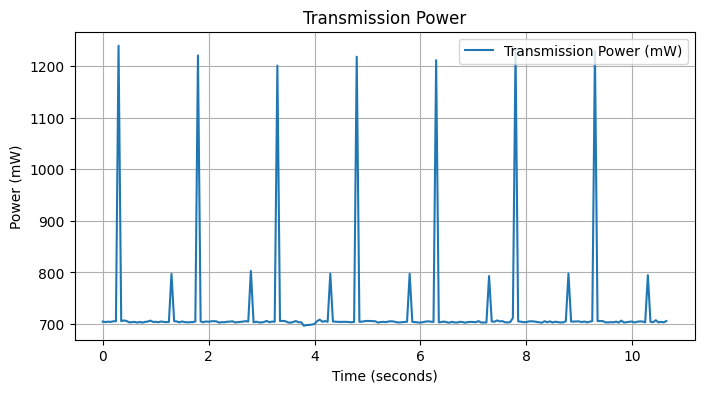

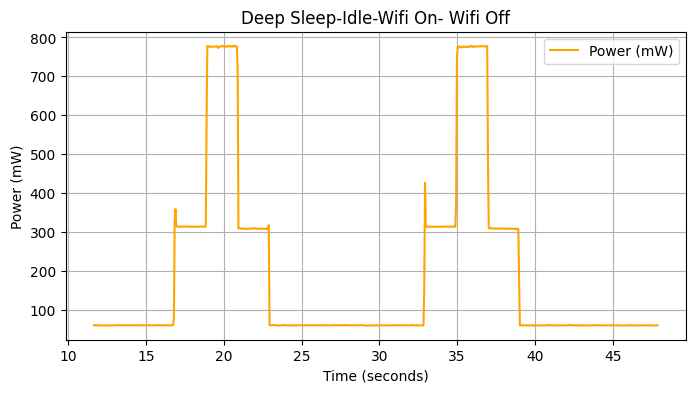

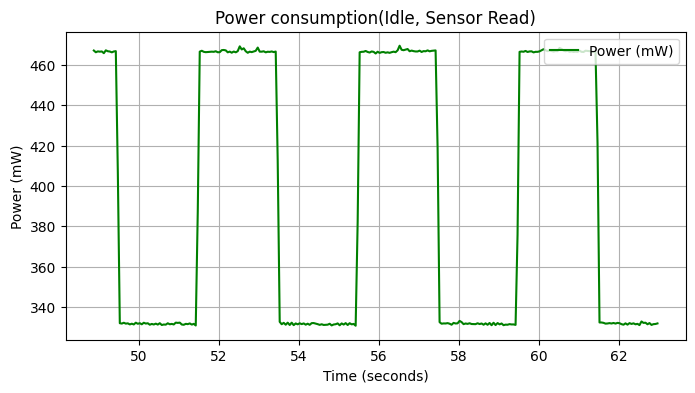

In [ ]:

df_transmission = pd.read_csv('transmission_power.csv')
df_transmission['Timestamp'] = pd.to_datetime(df_transmission['Timestamp'])
df_transmission['Seconds'] = (df_transmission['Timestamp'] - df_transmission['Timestamp'].iloc[0]).dt.total_seconds()
last_time_transmission = df_transmission['Seconds'].iloc[-1]

df_deep_sleep = pd.read_csv('deep_sleep.csv')
df_deep_sleep['Timestamp'] = pd.to_datetime(df_deep_sleep['Timestamp'])
df_deep_sleep['Seconds'] = (df_deep_sleep['Timestamp'] - df_deep_sleep['Timestamp'].iloc[0]).dt.total_seconds()
df_deep_sleep['Seconds'] += (last_time_transmission + 1)
last_time_deep_sleep = df_deep_sleep['Seconds'].iloc[-1]

df_sensor = pd.read_csv('sensor_read.csv')
df_sensor['Timestamp'] = pd.to_datetime(df_sensor['Timestamp'])
df_sensor['Seconds'] = (df_sensor['Timestamp'] - df_sensor['Timestamp'].iloc[0]).dt.total_seconds()
df_sensor['Seconds'] += (last_time_deep_sleep + 1)

plt.figure(figsize=(8, 4))
plt.plot(df_transmission['Seconds'], df_transmission['Data'], label='Transmission Power (mW)')
plt.xlabel('Time (seconds)')
plt.ylabel('Power (mW)')
plt.title('Transmission Power')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_deep_sleep['Seconds'], df_deep_sleep['Data'], label='Power (mW)', color='orange')
plt.xlabel('Time (seconds)')
plt.ylabel('Power (mW)')
plt.title('Deep Sleep-Idle-Wifi On- Wifi Off')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_sensor['Seconds'], df_sensor['Data'], label='Power (mW)', color='green')
plt.xlabel('Time (seconds)')
plt.ylabel('Power (mW)')
plt.title('Power consumption(Idle, Sensor Read)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [ ]:
# save data of tx in a new var called Data

power = df_transmission['Data'].values
# define Thershold
min_height = 750
#Find the peek
peaks, properties = find_peaks(power, height=min_height)
peak_values = power[peaks]
split_threshold = 1000
low_peaks  = peak_values[peak_values < split_threshold]
high_peaks = peak_values[peak_values >= split_threshold]
# calculte mean
mean_low  = np.mean(low_peaks)  if len(low_peaks)  > 0 else np.nan
mean_high = np.mean(high_peaks) if len(high_peaks) > 0 else np.nan


# thereshold, they are extracted from CSV file
deep_sleep_threshold = 300
wifi_on_threshold    = 750
boot_threshold       = 500
threshold_high = 460
threshold_low  = 340

# Function to classfy between each step
def classify_state(power):
    if power < deep_sleep_threshold:
        return "Deep Sleep"
    elif power < boot_threshold and power > deep_sleep_threshold:
        return "boot"
    elif power < wifi_on_threshold:
        return "Wi-Fi Off"
    else:
        return "Wi-Fi On"
def classify_state1(power):
    if power > threshold_high:
        return "sensor reading"
    elif power < threshold_low:
        return "Idle"

df_deep_sleep['State'] = df_deep_sleep['Data'].apply(classify_state)
df_sensor['State'] = df_sensor['Data'].apply(classify_state1)

mean_deep_sleep = df_deep_sleep[df_deep_sleep['State'] == "Deep Sleep"]['Data'].mean()
mean_wifi_off   = df_deep_sleep[df_deep_sleep['State'] == "Wi-Fi Off"]['Data'].mean()
mean_wifi_on    = df_deep_sleep[df_deep_sleep['State'] == "Wi-Fi On"]['Data'].mean()
mean_idle    = df_sensor[df_sensor['State'] == "Idle"]['Data'].mean()
mean_sensor    = df_sensor[df_sensor['State'] == "sensor reading"]['Data'].mean()
mean_boot    = df_deep_sleep[df_deep_sleep['State'] == "boot"]['Data'].mean()
print("Mean of Deep Sleep: {:.2f} mW".format(mean_deep_sleep))
print("Mean of Boot: {:.2f} mW".format(mean_boot))
print("Mean of Wi-Fi Off: {:.2f} mW".format(mean_wifi_off))
print("Mean of Wi-Fi On:  {:.2f} mW".format(mean_wifi_on))
print(f"Mean Idle: {mean_idle:.2f} mW")
print(f"Mean Sensor Reading: {mean_sensor:.2f} mW")
print(f"Mean power at 2 dBm:    {mean_low:.2f} mW")
print(f"Mean power at 19.5 dBm: {mean_high:.2f} mW")

Mean of Deep Sleep: 60.13 mW
Mean of Boot: 313.40 mW
Mean of Wi-Fi Off: 680.79 mW
Mean of Wi-Fi On:  776.62 mW
Mean Idle: 331.59 mW
Mean Sensor Reading: 466.74 mW
Mean power at 2 dBm:    797.29 mW
Mean power at 19.5 dBm: 1221.76 mW


## 🔋 2.2 Calculate Energy concumption

In [ ]:
# data for 1 cycle
sensor_duration = 24 /1000 #seconds
wifi_on_duration = 297/1000 #seconds
transmission_duration = 1/1000 #seconds
wifi_off_idle_duration = 100/1000 #seconds
Deep_sleep_duration = 27 #seconds # it is calaculted from student ID
energy_sensor = mean_sensor* sensor_duration
energy_wifi = mean_wifi_on * wifi_on_duration
energy_transmission = mean_low * transmission_duration
energy_deep_sleep = mean_deep_sleep* Deep_sleep_duration
energy_wifi_off = mean_wifi_off * wifi_off_idle_duration
# energy_idle = mean_idle * idle_duration
total_energy_mJ = energy_sensor + energy_transmission + energy_deep_sleep + energy_wifi + energy_wifi_off

total_energy_J = total_energy_mJ / 1000  # convert mJ to Joules
print(f'Energy Sensor: {energy_sensor:.2f} mJ')
print(f"Energy transmission: {energy_transmission:.2f} mJ")
print(f"Energy Deep Sleep: {energy_deep_sleep:.2f} mJ")
print(f"Energy Idle: {energy_wifi:.2f} mJ")
print(f"Energy Wifi Off: {energy_wifi_off:.2f} mJ")
print(f"Total Energy per cycle: {total_energy_J:.2f} Joules")

Energy Sensor: 11.20 mJ
Energy transmission: 0.80 mJ
Energy Deep Sleep: 1623.64 mJ
Energy Idle: 230.66 mJ
Energy Wifi Off: 68.08 mJ
Total Energy per cycle: 1.93 Joules


## ⏳ Estimate Time

In [ ]:
life_time_battery = 17133 # It is extracted from student ID
cycle_energy = life_time_battery/total_energy_J
cycle_time = transmission_duration + Deep_sleep_duration + sensor_duration + wifi_on_duration + wifi_off_idle_duration
total_active_time = cycle_time * cycle_energy # per sec
total_active_time = total_active_time/3600 # per hour
print(f'Total active time {total_active_time:.2f} hours')

Total active time 67.47 hours


---
# Part 3: Improvements to Reduce Energy Use

Improvements to reduce energy use can be proposed by checking the system requirements. For example, how often occupancy changes must be found and how reliably data must be sent can show where energy can be saved. Some solution can be:

## Change Deep Sleep Time
- Longer sleep time is used if constant sensing is not needed.  
- For example, In our project we use 27 sec to go deep sleep. To reduce consumption of energy, we can change it to 1 min at least.

## Change the behavior of Transmission
- Data is sent only when a change in occupancy is found (occupied → free or free → occupied).  
- Extra messages are not sent if the state has not changed.

To do this, we can add code below to send data whenever the module sense any change in the spot.
```c
void setup() {
  // Starting the Serial Communication
  Serial.begin(115200);

  // Printing timestamp when Serial is woken up
  Serial.println("Wakeup at: " + String(millis()));

  // Setting the TRIG pin as an output
  pinMode(TRIG, OUTPUT);

  // Setting the ECHO pin as an input
  pinMode(ECHO, INPUT);

  // Checking the parking spot
  String result = check_distance();

  if (result == "Free") {
    wifi_setup(result);
  }
}
```
## Optimize the Power Settings of Transmission
- Lower transmission power is used if the sink is near.  
- A more energy-efficient protocol or data rate is chosen if possible.

## Hardware-Level Optimization
- Low-power libraries or microcontroller features (like deep sleep or RTC wakeup) are used.  
- Sensors that use less current or have low-power modes built in are chosen.

## Local Data Processing
- Data is filtered or compressed on the node.  
- This reduces the size of the data and shortens transmission time.

---
# Part 4: Optimization

Now studies how a sink is placed in a wireless sensor network to keep energy use low. Ten sensors are located in a parking lot. Each sensor has a known (x, y) position.

## Sensor and Data Parameter
- 📬 Each sensor sends a status update every 10 minutes.  
- 📑 The packet size is 2000 bits.  
- 🔋 Each sensor starts with 5 mJ of energy.

## Energy Parameter
- 📡 The radio hardware uses 50 nJ for each bit sent.  
- 🎯 The transmission energy depends on the distance (d) between a sensor and the sink:
 \$$
    \text{Energy} = k \times d^2 \times (\text{bits}),
  $$ \

  where $$ k = 1 nJ/bit/m²$$
- 📈 The total energy to send one packet is:
$$
    \text{Energy per packet} = (\text{Packet Size}) \times \big(\text{Radio Cost} + k \times d^2\big).
$$



## Part 4-a: Find the Lifetime of the *System*

In [ ]:
import math

# Sensor positions
sensors = {
    "S1": (1, 2),
    "S2": (10, 3),
    "S3": (4, 8),
    "S4": (15, 7),
    "S5": (6, 1),
    "S6": (9, 12),
    "S7": (14, 4),
    "S8": (3, 10),
    "S9": (7, 7),
    "S10": (12, 14)
}

# Sink position
sink = (20, 20)

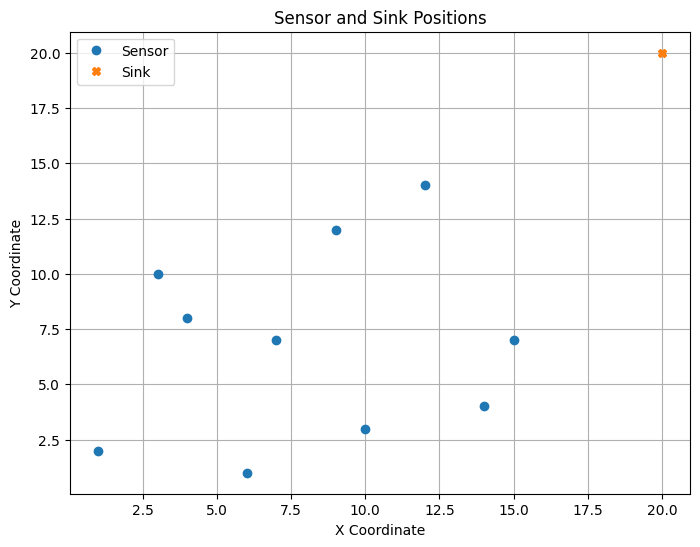

In [ ]:
sensor_x = [coord[0] for coord in sensors.values()]
sensor_y = [coord[1] for coord in sensors.values()]
sink_x = sink[0]
sink_y = sink[1]

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(sensor_x, sensor_y, 'o', label='Sensor')
plt.plot(sink_x, sink_y, 'X', label='Sink')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Sensor and Sink Positions')
plt.legend()
plt.grid(True, zorder=0)
plt.show()



## Goal 🎯

The goal of the code is to determine the lifetime of each sensor by calculating the energy used per packet and the number of transmissions possible with the initial energy available. The sensor with the shortest lifetime is identified, which is used to estimate the overall system lifetime.


In [ ]:
# Initialization parameters
b = 2000                   # Packet size in bits
Ec = 50                    # TX/RX circuitry energy in nJ/bit
k = 1                      # Transmission energy coefficient in nJ/bit/m^2
initial_energy_nJ = 5e6    # Initial energy per sensor in nJ (5 mJ = 5e6 nJ)
update_interval = 10       # Transmission interval in minutes

# Function to compute Euclidean distance
def euclidean_distance(sensor, sink):
    return math.sqrt((sink[0] - sensor[0])**2 + (sink[1] - sensor[1])**2)

# Dictionary to store results
results = {}

# Compute lifetime for each sensor
for sensor, pos in sensors.items():
    d = euclidean_distance(pos, sink)
    d2 = d**2
    energy_per_packet = b * (Ec + d2)  # in nJ
    transmissions = initial_energy_nJ / energy_per_packet
    lifetime = transmissions * update_interval  # in minutes
    results[sensor] = {
        "distance": d,
        "energy_per_packet": energy_per_packet,
        "transmissions": transmissions,
        "lifetime_minutes": lifetime
    }

# Find the sensor with the minimum lifetime
min_sensor = min(results, key=lambda s: results[s]["lifetime_minutes"])
min_lifetime = results[min_sensor]["lifetime_minutes"]

# Print out the details
print("Sensor details and lifetime (in minutes):")
for sensor, data in results.items():
    print(f"{sensor}: Distance = {data['distance']:.2f} m, Energy/Packet = {data['energy_per_packet']:.0f} nJ, "
          f"Transmissions = {data['transmissions']:.2f}, Lifetime = {data['lifetime_minutes']:.2f} min")

print("\nSystem lifetime (until the first sensor dies):")
print(f"{min_sensor} dies after approximately {min_lifetime:.2f} minutes")


Sensor details and lifetime (in minutes):
S1: Distance = 26.17 m, Energy/Packet = 1470000 nJ, Transmissions = 3.40, Lifetime = 34.01 min
S2: Distance = 19.72 m, Energy/Packet = 878000 nJ, Transmissions = 5.69, Lifetime = 56.95 min
S3: Distance = 20.00 m, Energy/Packet = 900000 nJ, Transmissions = 5.56, Lifetime = 55.56 min
S4: Distance = 13.93 m, Energy/Packet = 488000 nJ, Transmissions = 10.25, Lifetime = 102.46 min
S5: Distance = 23.60 m, Energy/Packet = 1214000 nJ, Transmissions = 4.12, Lifetime = 41.19 min
S6: Distance = 13.60 m, Energy/Packet = 470000 nJ, Transmissions = 10.64, Lifetime = 106.38 min
S7: Distance = 17.09 m, Energy/Packet = 684000 nJ, Transmissions = 7.31, Lifetime = 73.10 min
S8: Distance = 19.72 m, Energy/Packet = 878000 nJ, Transmissions = 5.69, Lifetime = 56.95 min
S9: Distance = 18.38 m, Energy/Packet = 776000 nJ, Transmissions = 6.44, Lifetime = 64.43 min
S10: Distance = 10.00 m, Energy/Packet = 300000 nJ, Transmissions = 16.67, Lifetime = 166.67 min

System l

## Part 4-b: Finding the Optimal Sink Position

The goal is to maximize the system lifetime by finding the optimal sink position. The coordinates `(xs, ys)` are selected to minimize the energy consumption of the worst-case sensor.

- **Welzl's algorithm** is used to compute the [Minimum Enclosing Circle (MEC)](https://en.wikipedia.org/wiki/Smallest-circle_problem) that covers all sensors.
- The **Welzl's algorithm** finds the smallest circle that encloses all sensors, ensuring that the distances between the sink and each sensor are minimized.
- The center of this circle is chosen as the optimal sink position.
- The code below demonstrates this approach.


In [ ]:
import math
import random

# Euclidean distance between two points
def distance(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

# Compute circle from two points
def circle_from_two_points(p, q):
    center = ((p[0] + q[0]) / 2.0, (p[1] + q[1]) / 2.0)
    radius = distance(p, q) / 2.0
    return center, radius

# Compute circle from three points
def circle_from_three_points(p, q, r):
    ax, ay = p
    bx, by = q
    cx, cy = r
    d = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    if d == 0:
        # Points are collinear; return an infinite circle
        return None, float('inf')
    ux = ((ax**2 + ay**2) * (by - cy) + (bx**2 + by**2) * (cy - ay) + (cx**2 + cy**2) * (ay - by)) / d
    uy = ((ax**2 + ay**2) * (cx - bx) + (bx**2 + by**2) * (ax - cx) + (cx**2 + cy**2) * (bx - ax)) / d
    center = (ux, uy)
    radius = distance(center, p)
    return center, radius

# Check if a point is inside a circle
def is_in_circle(circle, point, tol=1e-8):
    center, radius = circle
    return distance(center, point) <= radius + tol

# Welzl's algorithm for the Minimum Enclosing Circle (MEC)
def minimum_enclosing_circle(points, boundary):
    if not points or len(boundary) == 3:
        if len(boundary) == 0:
            return ((0, 0), 0)
        elif len(boundary) == 1:
            return (boundary[0], 0)
        elif len(boundary) == 2:
            return circle_from_two_points(boundary[0], boundary[1])
        else:  # len(boundary) == 3
            return circle_from_three_points(boundary[0], boundary[1], boundary[2])

    # Remove a random point from the list
    p = points.pop()
    # Get the MEC for the remaining points
    circle = minimum_enclosing_circle(points, boundary)

    if is_in_circle(circle, p):
        points.append(p)  # Restore the point
        return circle
    else:
        # Otherwise, p must be on the boundary of the MEC.
        boundary.append(p)
        result = minimum_enclosing_circle(points, boundary)
        boundary.pop()  # Remove p from boundary after processing
        points.append(p)  # Restore the point
        return result

# Create a copy of the sensor list and randomize the order
points_copy = sensors.copy()
random.shuffle(points_copy)

# Compute the Minimum Enclosing Circle using Welzl's algorithm
(optimal_center, optimal_radius) = minimum_enclosing_circle(points_copy, [])

print("Optimal sink position (xs, ys): ({:.2f}, {:.2f})".format(optimal_center[0], optimal_center[1]))
print("Worst-case distance (radius): {:.2f} m".format(optimal_radius))


Optimal sink position (xs, ys): (6.87, 7.66)
Worst-case distance (radius): 8.16 m


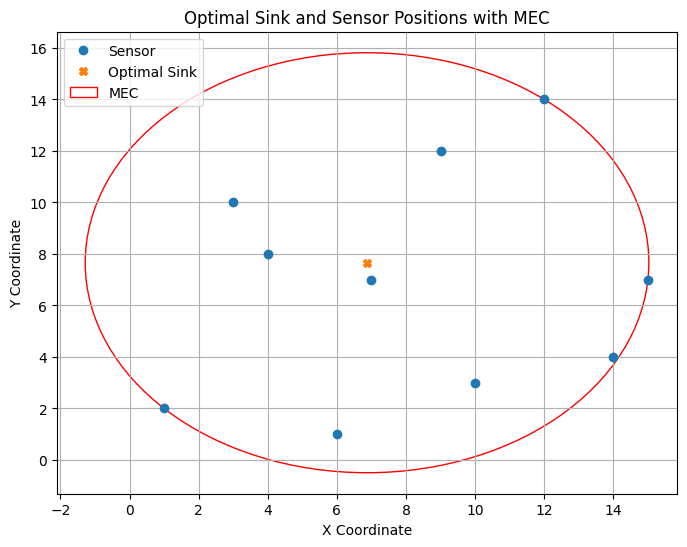

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(sensor_x, sensor_y, 'o', label='Sensor')
plt.plot(optimal_center[0], optimal_center[1], 'X', label='Optimal Sink')

circle = plt.Circle(optimal_center, optimal_radius, color='r', fill=False, label='MEC')
plt.gca().add_patch(circle)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Optimal Sink and Sensor Positions with MEC')
plt.legend()
plt.grid(True, zorder=0)
plt.show()


In [ ]:
# Compare the result between when sink located in (20,20) and when it is located in optimal position which calculted in the later step
for label, sink in sink_positions.items():
    print(f"\n--- Sink Position: {label} ---")
    system_lifetime = float('inf')
    for sensor, pos in sensors.items():
        d, energy_packet, transmissions, lifetime = compute_sensor_lifetime(pos, sink)
        system_lifetime = min(system_lifetime, lifetime)
        print(f"{sensor}: Distance = {d:.2f} m, Energy/Packet = {energy_packet:.0f} nJ, "
              f"Transmissions = {transmissions:.2f}, Lifetime = {lifetime:.2f} min")
    print(f"\nSystem lifetime (until first sensor dies) = {system_lifetime:.2f} minutes")



--- Sink Position: Fixed Sink (20,20) ---
S1: Distance = 26.17 m, Energy/Packet = 1470000 nJ, Transmissions = 3.40, Lifetime = 34.01 min
S2: Distance = 19.72 m, Energy/Packet = 878000 nJ, Transmissions = 5.69, Lifetime = 56.95 min
S3: Distance = 20.00 m, Energy/Packet = 900000 nJ, Transmissions = 5.56, Lifetime = 55.56 min
S4: Distance = 13.93 m, Energy/Packet = 488000 nJ, Transmissions = 10.25, Lifetime = 102.46 min
S5: Distance = 23.60 m, Energy/Packet = 1214000 nJ, Transmissions = 4.12, Lifetime = 41.19 min
S6: Distance = 13.60 m, Energy/Packet = 470000 nJ, Transmissions = 10.64, Lifetime = 106.38 min
S7: Distance = 17.09 m, Energy/Packet = 684000 nJ, Transmissions = 7.31, Lifetime = 73.10 min
S8: Distance = 19.72 m, Energy/Packet = 878000 nJ, Transmissions = 5.69, Lifetime = 56.95 min
S9: Distance = 18.38 m, Energy/Packet = 776000 nJ, Transmissions = 6.44, Lifetime = 64.43 min
S10: Distance = 10.00 m, Energy/Packet = 300000 nJ, Transmissions = 16.67, Lifetime = 166.67 min

System 

## Part4-C: Discuss the Trade-offs
### *Trade-offs of Fixed vs. Dynamic Sink Position*  

---

📌 **Fixed Sink Position**  
- **Simplicity**: With a sink in a single location, the network topology remains unchanged, making routing and scheduling straightforward.  
- **Energy Drain**: Sensors far from the sink must transmit data over longer distances, causing their batteries to deplete faster and potentially shortening the overall network lifetime.

📌 **Dynamic Sink Position**  
- **Balancing Energy**: The sink can be periodically repositioned closer to sensors with high data loads or low remaining energy, helping distribute energy consumption more evenly and often extending the system lifetime.  
- **Complexity & Overhead**: Frequent repositioning adds management complexity, potential downtime during movement, and additional energy costs associated with mobility.

---

### **Key Trade-offs**  
1. <u>**Implementation Complexity**</u> vs. <mark>Potential Lifetime Gains</mark>  
2. <u>**Routing Stability**</u> vs. <mark>Fair Distribution of Energy Consumption</mark>  
3. <u>**Ease of Static Deployment**</u> vs. <mark>Adaptive Response to Changing Network Conditions</mark>  

